# QETHOS — VQC Quantum Pipeline

## Step 1 — Storage setup (Colab Drive / NRP persistent volume)

In [1]:
import os

def detect_env():
    try:
        import google.colab  # noqa: F401
        return "colab"
    except ImportError:
        if os.path.exists("/content"):
            return "other"
        return "nrp" if os.environ.get("JUPYTERHUB_USER") else "other"

ENV = detect_env()
print("Environment detected:", ENV)

if ENV == "colab":
    from google.colab import drive
    drive.mount("/content/drive")
    BASE_DIR = "/content/drive/MyDrive/QETHOS"
else:
    # NRP: point at your persistent volume (PVC). EDIT if yours differs.
    BASE_DIR = os.environ.get("QETHOS_BASE", os.path.expanduser("~/QETHOS"))

os.makedirs(BASE_DIR, exist_ok=True)
print("BASE_DIR:", BASE_DIR)

Environment detected: nrp
BASE_DIR: /home/jovyan/QETHOS


## Step 2 — Install Required Libraries

In [2]:
# Run once per fresh environment.
!pip install pennylane --quiet
!pip install xgboost --quiet
!pip install adversarial-robustness-toolbox --quiet
print("Libraries installed successfully.")

Libraries installed successfully.


## Step 3 — Configure Paths and Hyperparameters

In [3]:
# Paths derive from BASE_DIR (set in Step 1), so this runs unchanged on Colab AND NRP.
BALANCED_INPUT = os.path.join(BASE_DIR, "Data", "ctgan_balanced_400k_dataset.csv")
OUTPUT_DIR     = os.path.join(BASE_DIR, "results") + os.sep
os.makedirs(OUTPUT_DIR, exist_ok=True)

QML_SAMPLE_SIZE  = 20_000    # 10,000 fraud + 10,000 legitimate
VAL_RATIO        = 0.10      # -> 2,000 validation
TEST_RATIO       = 0.25      # -> 5,000 test  (matches QSVM's 5000)

# VQC HYPERPARAMETERS
N_QUBITS         = 9         # one qubit per AGA feature
N_LAYERS         = 6         # re-uploading layers (each layer re-encodes the data)
LEARNING_RATE    = 0.01      # Adam learning rate
N_EPOCHS         = 80        # early "best on validation" checkpointing makes more epochs safe
BATCH_SIZE       = 64
RANDOM_SEED      = 42
RUN_VQC_MULTISEED = True
VQC_SEEDS = [42, 7, 123]
# ----------------------------------------------------------------------------
# WHAT TO RUN (configurable, like the QSVM notebook)
# ----------------------------------------------------------------------------
RUN_BASELINES = False    # False -> train/evaluate the VQC ONLY (skip RF + XGBoost).
                         # Set True to also run the classical comparison.

# ART adversarial-robustness knobs (used in the ART section at the end)
RUN_ART      = True      # master switch for the robustness section
ART_N_ADV    = 200       # samples for transfer FGSM/PGD (cheap)
ART_EPSILONS = [0.05, 0.1, 0.2, 0.3, 0.5]   # perturbation budgets (in encoded [-1,1] units)
RUN_HSJ      = True     # HopSkipJump black-box (slow); set True when you have time
ART_N_HSJ    = 50        # samples for HopSkipJump


QUANTUM_DEVICE = "lightning.qubit" 

print("Configuration loaded.")
print(f"  RUN_BASELINES={RUN_BASELINES} | RUN_ART={RUN_ART} | RUN_HSJ={RUN_HSJ}")

Configuration loaded.
  RUN_BASELINES=False | RUN_ART=True | RUN_HSJ=False


## Step 4 — Import Libraries

In [4]:
import pandas as pd
import numpy as np
import pennylane as qml
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import QuantileTransformer, MinMaxScaler   # FIX: MinMaxScaler now imported
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
    precision_score, recall_score, f1_score, accuracy_score, roc_auc_score)
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import copy, os, time, warnings
warnings.filterwarnings('ignore')

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

DEVICE = torch.device('cpu')   # default.qubit runs on CPU; moving tensors to CUDA only adds transfer overhead
print(f'PennyLane : {qml.__version__} | PyTorch : {torch.__version__} | Device : {DEVICE}')

PennyLane : 0.45.1 | PyTorch : 2.5.1+cpu | Device : cpu


## Step 5 — Define the 9 AGA Features

In [5]:
AGA_FEATURES = ['length_to','block_number','gas_used','chain_id','total_gas_cost',
    'effective_gas_price','cumulative_gas_used','gas_price_ratio','length_log']
LABEL_COLUMN = 'flag'
print(f'{len(AGA_FEATURES)} features, {N_QUBITS} qubits')

9 features, 9 qubits


## Step 6 — Load the Balanced Dataset

In [6]:
if not os.path.exists(BALANCED_INPUT):
    raise FileNotFoundError(f'Balanced dataset not found at: {BALANCED_INPUT}')
df = pd.read_csv(BALANCED_INPUT)
print(f'Shape : {df.shape[0]:,} x {df.shape[1]}')
print(df[LABEL_COLUMN].value_counts())

Shape : 400,000 x 10
flag
1    200000
0    200000
Name: count, dtype: int64


## Step 7 — Extract Stratified QML Sample

In [7]:
samples_per_class = QML_SAMPLE_SIZE // 2
df_fraud = df[df[LABEL_COLUMN] == 1].sample(n=samples_per_class, random_state=RANDOM_SEED)
df_legit = df[df[LABEL_COLUMN] == 0].sample(n=samples_per_class, random_state=RANDOM_SEED)
df_qml = (pd.concat([df_fraud, df_legit], ignore_index=True)
            .sample(frac=1, random_state=RANDOM_SEED).reset_index(drop=True))
print(f'QML sample : {df_qml.shape[0]:,} ({(df_qml[LABEL_COLUMN]==1).sum():,} fraud / {(df_qml[LABEL_COLUMN]==0).sum():,} legit)')

QML sample : 20,000 (10,000 fraud / 10,000 legit)


## Step 8 — Train / Validation / Test split (FIX: dedicated validation set)

70% train / 15% validation / 15% test. The validation set is used for (a) picking the
best epoch and (b) tuning the decision threshold. The test set is used **once**, for
the final reported numbers. Previously the threshold was tuned directly on the test
set — that is data leakage and inflates the reported F1.

In [8]:
X = df_qml[AGA_FEATURES].values.astype(np.float32)
y = df_qml[LABEL_COLUMN].values.astype(np.float32)

# first carve off the test set, then split the remainder into train/val
X_trval, X_test, y_trval, y_test = train_test_split(
    X, y, test_size=TEST_RATIO, stratify=y, random_state=RANDOM_SEED)

val_fraction_of_trval = VAL_RATIO / (1.0 - TEST_RATIO)
X_train, X_val, y_train, y_val = train_test_split(
    X_trval, y_trval, test_size=val_fraction_of_trval, stratify=y_trval, random_state=RANDOM_SEED)

print(f'Train {X_train.shape[0]:,} | Val {X_val.shape[0]:,} | Test {X_test.shape[0]:,}')

Train 13,000 | Val 2,000 | Test 5,000


## Step 9 — Quantile (rank) encoding (FIX: replaces RobustScaler + tanh)

`tanh` after RobustScaler fixed the "all angles near zero" problem but created a new
one: every value beyond a few IQRs saturates to ±1.0, so the most extreme — and most
fraud-indicative — gas values all become the *same* rotation angle. Tree models split
on those tails directly, which is part of why they looked so much stronger.

`QuantileTransformer(output_distribution='uniform')` maps each feature to its rank,
spreading values *uniformly* over [0, 1]. We then rescale to (-1, 1). No saturation:
distinct values stay distinct, including in the tails, and the encoded angles use the
full RY range. Fitted on train only, as before.

In [9]:
qt = QuantileTransformer(output_distribution='uniform',
                         n_quantiles=min(1000, len(X_train)),
                         random_state=RANDOM_SEED)
X_train_s = (qt.fit_transform(X_train) * 2.0 - 1.0).astype(np.float32)
X_val_s   = (qt.transform(X_val)   * 2.0 - 1.0).astype(np.float32)
X_test_s  = (qt.transform(X_test)  * 2.0 - 1.0).astype(np.float32)

print(f'Encoded train range: [{X_train_s.min():.3f}, {X_train_s.max():.3f}]')
print(f'Encoded train std per feature (want all well above 0):')
print(np.round(X_train_s.std(axis=0), 3))

Encoded train range: [-1.000, 1.000]
Encoded train std per feature (want all well above 0):
[0.169 0.576 0.551 0.87  0.576 0.576 0.577 0.    0.561]


## Step 10 — Define the Quantum Device

In [10]:
dev = qml.device(QUANTUM_DEVICE, wires=N_QUBITS)
print(f'Device : {dev.name} | Qubits : {N_QUBITS}')

Device : lightning.qubit | Qubits : 9


## Step 11 — VQC: trainable-scale data re-uploading, dual-axis encoding

Three upgrades over the previous circuit:

- **Trainable encoding scales/shifts** (`enc_scale`, `enc_shift`, one pair per layer per
  feature): instead of the fixed `RY(pi * x)`, each layer applies
  `RY(a * x + b)` with `a, b` learned. The circuit learns *how strongly* each feature
  should rotate its qubit — this is the standard trick from the data re-uploading
  literature (Perez-Salinas et al., 2020) and usually the single biggest accuracy gain.
- **Dual-axis encoding**: each feature is written into both RY and RZ every layer,
  doubling the information injected per re-upload.
- Ring CNOT entanglement and all-qubit PauliZ measurement are kept from v2.

In [11]:
if QUANTUM_DEVICE == "lightning.qubit":
    DIFF_METHOD = "adjoint"
else:
    DIFF_METHOD = "backprop"

def _circuit(inputs, enc_scale, enc_shift, weights):
    # inputs:    (..., N_QUBITS)
    # enc_scale: (N_LAYERS, N_QUBITS)   trainable encoding scales
    # enc_shift: (N_LAYERS, N_QUBITS)   trainable encoding shifts
    # weights:   (N_LAYERS, N_QUBITS, 2) trainable rotations
    for layer in range(N_LAYERS):
        # --- data re-uploading with TRAINABLE scale and shift ---
        for i in range(N_QUBITS):
            angle = enc_scale[layer, i] * inputs[..., i] + enc_shift[layer, i]
            qml.RY(angle, wires=i)
            qml.RZ(angle, wires=i)          # dual-axis: same feature on a second axis
        # --- trainable rotations ---
        for q in range(N_QUBITS):
            qml.RY(weights[layer, q, 0], wires=q)
            qml.RZ(weights[layer, q, 1], wires=q)
        # --- ring entanglement ---
        for q in range(N_QUBITS - 1):
            qml.CNOT(wires=[q, q + 1])
        qml.CNOT(wires=[N_QUBITS - 1, 0])
    return [qml.expval(qml.PauliZ(i)) for i in range(N_QUBITS)]

vqc_qnode = qml.QNode(_circuit, dev, interface='torch', diff_method=DIFF_METHOD)
print('VQC defined: trainable-scale re-uploading,', N_LAYERS, 'layers, dual-axis encoding, all-qubit measurement.')

VQC defined: trainable-scale re-uploading, 6 layers, dual-axis encoding, all-qubit measurement.


## Step 12 — Model: TorchLayer + linear head

- Encoding scales start at pi (recovering the old fixed behavior as the starting
  point), shifts start at 0, rotation weights start small (`uniform(-0.1, 0.1)`).
  Small rotation init plus active data encoding avoids both failure modes: the circuit
  is *not* near-identity (the data encoding guarantees signal from epoch 1), and we
  avoid the random-deep-circuit regime associated with barren plateaus.
- The 9 measured expectations feed `Linear(9 -> 1)` producing a logit, paired with
  `BCEWithLogitsLoss`, same as v2.

In [12]:
class QETHOSModel(nn.Module):
    def __init__(self, n_qubits, n_layers):
        super().__init__()
        weight_shapes = {
            'enc_scale': (n_layers, n_qubits),
            'enc_shift': (n_layers, n_qubits),
            'weights':   (n_layers, n_qubits, 2),
        }
        init_methods = {
            'enc_scale': lambda t: torch.nn.init.constant_(t, np.pi),
            'enc_shift': lambda t: torch.nn.init.zeros_(t),
            'weights':   lambda t: torch.nn.init.uniform_(t, -0.1, 0.1),
        }
        self.qlayer = qml.qnn.TorchLayer(vqc_qnode, weight_shapes, init_method=init_methods)
        self.head = nn.Linear(n_qubits, 1)
    def forward(self, x):
        q = self.qlayer(x)                  # (batch, n_qubits)
        return self.head(q).squeeze(-1)     # logits

model = QETHOSModel(N_QUBITS, N_LAYERS).to(DEVICE)
print('Params:', sum(p.numel() for p in model.parameters()))

Params: 226


## Step 13 — DataLoaders

In [13]:
X_tr = torch.tensor(X_train_s, dtype=torch.float32)
y_tr = torch.tensor(y_train,   dtype=torch.float32)
X_va = torch.tensor(X_val_s,   dtype=torch.float32)
y_va = torch.tensor(y_val,     dtype=torch.float32)
X_te = torch.tensor(X_test_s,  dtype=torch.float32)
y_te = torch.tensor(y_test,    dtype=torch.float32)

train_loader = DataLoader(TensorDataset(X_tr, y_tr), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_va, y_va), batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(TensorDataset(X_te, y_te), batch_size=BATCH_SIZE, shuffle=False)
print('Train batches', len(train_loader), '| Val batches', len(val_loader), '| Test batches', len(test_loader))

Train batches 204 | Val batches 32 | Test batches 79


## Step 14 — Loss, Optimizer, LR scheduler

In [14]:
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max',
                                                 factor=0.5, patience=8)
print('Loss: BCEWithLogitsLoss | Optimizer: Adam | lr', LEARNING_RATE, '| LR halves if val F1 plateaus 8 epochs')

Loss: BCEWithLogitsLoss | Optimizer: Adam | lr 0.01 | LR halves if val F1 plateaus 8 epochs


## Step 15 — Train with validation-based checkpointing (FIX)

Every epoch we compute validation F1 (at the default 0.5 cutoff — fine for tracking)
and keep a copy of the best-so-far weights. At the end we restore that checkpoint, so
the final model is the one that generalized best, not whatever the last epoch produced.

In [15]:
def collect_probs(loader, mdl):
    mdl.eval()
    ps, ys = [], []
    with torch.no_grad():
        for Xb, yb in loader:
            p = torch.sigmoid(mdl(Xb.to(DEVICE))).cpu().numpy()
            ps.extend(p); ys.extend(yb.numpy())
    return np.array(ps), np.array(ys)

train_losses, train_accs, val_f1s = [], [], []
best_val_f1, best_state = -1.0, None

print(f'Training for up to {N_EPOCHS} epochs...')
t0 = time.time()
for epoch in range(1, N_EPOCHS + 1):
    model.train()
    loss_sum = correct = total = 0
    for Xb, yb in train_loader:
        Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        logits = model(Xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        loss_sum += loss.item() * len(yb)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == yb).sum().item(); total += len(yb)
    train_losses.append(loss_sum/total); train_accs.append(correct/total)

    # validation F1 for checkpointing + LR schedule
    val_p, val_y = collect_probs(val_loader, model)
    vf1 = f1_score(val_y, (val_p > 0.5).astype(int), zero_division=0)
    val_f1s.append(vf1)
    scheduler.step(vf1)
    if vf1 > best_val_f1:
        best_val_f1 = vf1
        best_state = copy.deepcopy(model.state_dict())

    if epoch % 5 == 0 or epoch == 1:
        print(f'Epoch {epoch:3d}/{N_EPOCHS} | loss {train_losses[-1]:.4f} | train acc {train_accs[-1]:.4f} | val F1 {vf1:.4f} | {time.time()-t0:.0f}s')

model.load_state_dict(best_state)
print(f'Done in {(time.time()-t0)/60:.1f} min. Restored best checkpoint (val F1 = {best_val_f1:.4f}).')

Training for up to 80 epochs...
Epoch   1/80 | loss 0.6435 | train acc 0.6745 | val F1 0.7426 | 349s
Epoch   5/80 | loss 0.2908 | train acc 0.8763 | val F1 0.8757 | 1755s
Epoch  10/80 | loss 0.2498 | train acc 0.8897 | val F1 0.8919 | 3502s
Epoch  15/80 | loss 0.2284 | train acc 0.9008 | val F1 0.8986 | 5244s
Epoch  20/80 | loss 0.2208 | train acc 0.9054 | val F1 0.9014 | 6975s
Epoch  25/80 | loss 0.2159 | train acc 0.9068 | val F1 0.9035 | 8710s
Epoch  30/80 | loss 0.2121 | train acc 0.9132 | val F1 0.9062 | 10442s
Epoch  35/80 | loss 0.1996 | train acc 0.9176 | val F1 0.9147 | 12180s
Epoch  40/80 | loss 0.1990 | train acc 0.9180 | val F1 0.9096 | 13924s
Epoch  50/80 | loss 0.1945 | train acc 0.9188 | val F1 0.9071 | 17404s
Epoch  55/80 | loss 0.1921 | train acc 0.9210 | val F1 0.9133 | 19154s
Epoch  60/80 | loss 0.1848 | train acc 0.9232 | val F1 0.9178 | 20900s
Epoch  65/80 | loss 0.1840 | train acc 0.9239 | val F1 0.9165 | 22634s
Epoch  70/80 | loss 0.1806 | train acc 0.9250 | val 

## Step 16 — Plot Training Curves

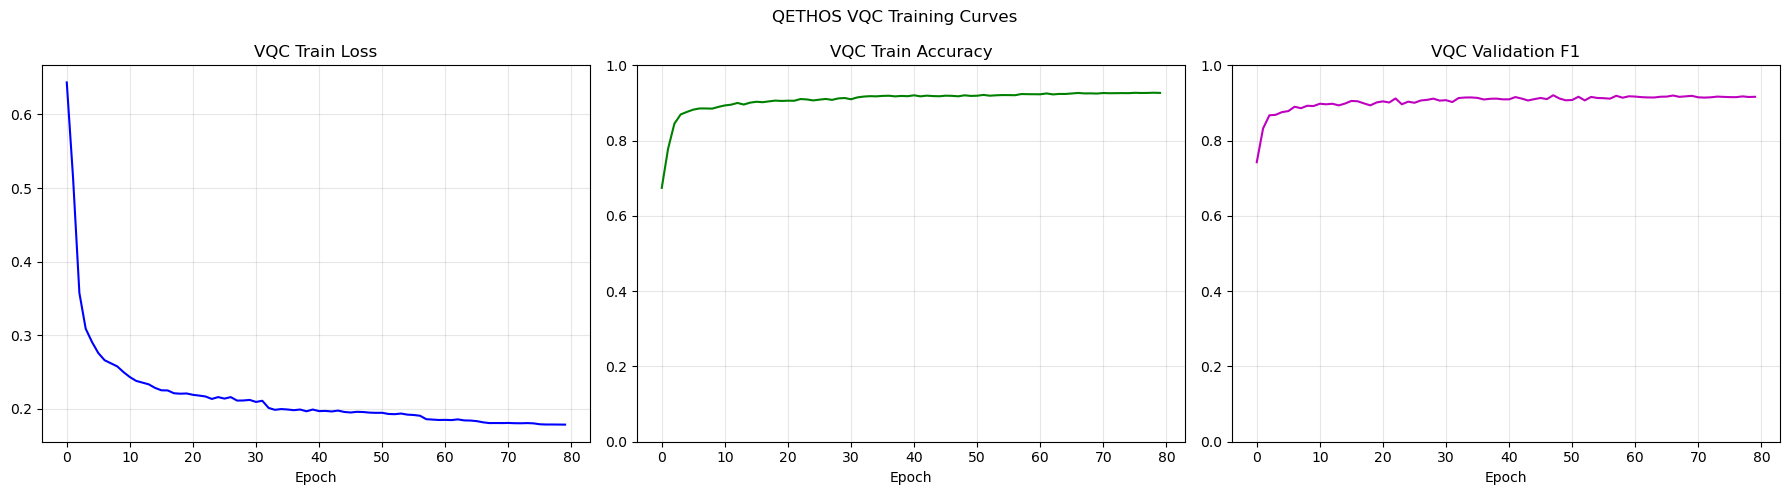

In [16]:
os.makedirs(OUTPUT_DIR, exist_ok=True)
fig, ax = plt.subplots(1, 3, figsize=(18,5))
ax[0].plot(train_losses, 'b'); ax[0].set_title('VQC Train Loss'); ax[0].set_xlabel('Epoch'); ax[0].grid(alpha=.3)
ax[1].plot(train_accs, 'g');  ax[1].set_title('VQC Train Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].set_ylim(0,1); ax[1].grid(alpha=.3)
ax[2].plot(val_f1s, 'm');     ax[2].set_title('VQC Validation F1'); ax[2].set_xlabel('Epoch'); ax[2].set_ylim(0,1); ax[2].grid(alpha=.3)
plt.suptitle('QETHOS VQC Training Curves'); plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}vqc_training_curves.png', dpi=150); plt.show()

## Step 17 — Tune threshold on VALIDATION, evaluate on TEST (FIX)

The threshold that maximizes F1 is found on the validation set, then applied —
untouched — to the test set. ROC-AUC is also reported since it doesn't depend on any
threshold at all.

In [17]:
# 1) tune threshold on validation
val_p, val_y = collect_probs(val_loader, model)
ths = np.linspace(0.1, 0.9, 81)
best_t = max(ths, key=lambda t: f1_score(val_y, (val_p > t).astype(int), zero_division=0))
print(f'Threshold chosen on validation : {best_t:.2f}')

# 2) final evaluation on the held-out test set
test_p, y_true = collect_probs(test_loader, model)
y_pred_vqc = (test_p > best_t).astype(int)

vqc_precision = precision_score(y_true, y_pred_vqc, zero_division=0)
vqc_recall    = recall_score(y_true, y_pred_vqc, zero_division=0)
vqc_f1        = f1_score(y_true, y_pred_vqc, zero_division=0)
vqc_accuracy  = accuracy_score(y_true, y_pred_vqc)
vqc_auc       = roc_auc_score(y_true, test_p)

print(f'Precision {vqc_precision:.4f} | Recall {vqc_recall:.4f} | F1 {vqc_f1:.4f} | Acc {vqc_accuracy:.4f} | ROC-AUC {vqc_auc:.4f}')
print(classification_report(y_true, y_pred_vqc, target_names=['Legitimate','Fraud']))

Threshold chosen on validation : 0.49
Precision 0.9040 | Recall 0.9188 | F1 0.9113 | Acc 0.9106 | ROC-AUC 0.9733
              precision    recall  f1-score   support

  Legitimate       0.92      0.90      0.91      2500
       Fraud       0.90      0.92      0.91      2500

    accuracy                           0.91      5000
   macro avg       0.91      0.91      0.91      5000
weighted avg       0.91      0.91      0.91      5000



In [18]:
# ===== Multi-seed stability for the VQC =====
# Retrains the VQC from scratch at each seed and reports mean ± std.
# COST: ~163 min per seed. 3 seeds ≈ 8 hours.


if RUN_VQC_MULTISEED:
    import copy, time
    seed_rows = []

    for sd in VQC_SEEDS:
        t_seed = time.time()
        print(f"\n{'='*50}\n=== SEED {sd} ===\n{'='*50}")

        # --- reseed everything ---
        np.random.seed(sd)
        torch.manual_seed(sd)

        # --- fresh stratified sample + split at this seed ---
        df_f = df[df[LABEL_COLUMN] == 1].sample(n=QML_SAMPLE_SIZE // 2, random_state=sd)
        df_l = df[df[LABEL_COLUMN] == 0].sample(n=QML_SAMPLE_SIZE // 2, random_state=sd)
        df_s = (pd.concat([df_f, df_l], ignore_index=True)
                  .sample(frac=1, random_state=sd).reset_index(drop=True))
        Xs = df_s[AGA_FEATURES].values.astype(np.float32)
        ys = df_s[LABEL_COLUMN].values.astype(np.float32)

        X_tv, X_te_s, y_tv, y_te_s = train_test_split(
            Xs, ys, test_size=TEST_RATIO, stratify=ys, random_state=sd)
        X_tr_s, X_va_s, y_tr_s, y_va_s = train_test_split(
            X_tv, y_tv, test_size=VAL_RATIO / (1.0 - TEST_RATIO),
            stratify=y_tv, random_state=sd)

        # --- quantile encoding, fit on train only ---
        qt_s = QuantileTransformer(output_distribution='uniform',
                                   n_quantiles=min(1000, len(X_tr_s)),
                                   random_state=sd)
        X_tr_e = (qt_s.fit_transform(X_tr_s) * 2.0 - 1.0).astype(np.float32)
        X_va_e = (qt_s.transform(X_va_s) * 2.0 - 1.0).astype(np.float32)
        X_te_e = (qt_s.transform(X_te_s) * 2.0 - 1.0).astype(np.float32)

        tr_loader = DataLoader(TensorDataset(torch.tensor(X_tr_e), torch.tensor(y_tr_s)),
                               batch_size=BATCH_SIZE, shuffle=True)
        va_loader = DataLoader(TensorDataset(torch.tensor(X_va_e), torch.tensor(y_va_s)),
                               batch_size=BATCH_SIZE)
        te_loader = DataLoader(TensorDataset(torch.tensor(X_te_e), torch.tensor(y_te_s)),
                               batch_size=BATCH_SIZE)

        # --- fresh model / optimizer / scheduler ---
        m = QETHOSModel(N_QUBITS, N_LAYERS).to(DEVICE)
        crit = nn.BCEWithLogitsLoss()
        opt = optim.Adam(m.parameters(), lr=LEARNING_RATE)
        sch = optim.lr_scheduler.ReduceLROnPlateau(opt, mode='max', factor=0.5, patience=8)

        best_f1, best_state = -1.0, None
        for epoch in range(1, N_EPOCHS + 1):
            m.train()
            for Xb, yb in tr_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                opt.zero_grad()
                loss = crit(m(Xb), yb)
                loss.backward()
                opt.step()
            vp, vy = collect_probs(va_loader, m)
            vf1 = f1_score(vy, (vp > 0.5).astype(int), zero_division=0)
            sch.step(vf1)
            if vf1 > best_f1:
                best_f1, best_state = vf1, copy.deepcopy(m.state_dict())
            if epoch % 20 == 0:
                print(f"  epoch {epoch}/{N_EPOCHS} | val F1 {vf1:.4f} | {(time.time()-t_seed)/60:.1f} min")
        m.load_state_dict(best_state)

        # --- threshold on val, evaluate once on test ---
        vp, vy = collect_probs(va_loader, m)
        ths = np.linspace(0.1, 0.9, 81)
        bt = max(ths, key=lambda t: f1_score(vy, (vp > t).astype(int), zero_division=0))
        tp, ty = collect_probs(te_loader, m)
        pred = (tp > bt).astype(int)

        seed_rows.append({
            "seed": sd,
            "Precision": precision_score(ty, pred, zero_division=0),
            "Recall":    recall_score(ty, pred, zero_division=0),
            "F1":        f1_score(ty, pred, zero_division=0),
            "Acc":       accuracy_score(ty, pred),
            "AUC":       roc_auc_score(ty, tp),
        })
        print(f"seed {sd}: F1={seed_rows[-1]['F1']:.4f} AUC={seed_rows[-1]['AUC']:.4f} "
              f"({(time.time()-t_seed)/60:.1f} min)")

    sdf = pd.DataFrame(seed_rows)
    print("\nPer-seed:"); print(sdf.to_string(index=False))
    print("\nMean ± std:")
    for col in ["Precision", "Recall", "F1", "Acc", "AUC"]:
        print(f"  {col:<10}: {sdf[col].mean():.4f} ± {sdf[col].std():.4f}")
    sdf.to_csv(f"{OUTPUT_DIR}vqc_multiseed.csv", index=False)
else:
    print("RUN_VQC_MULTISEED=False -> skipping.")


=== SEED 42 ===
  epoch 20/80 | val F1 0.9014 | 116.2 min
  epoch 60/80 | val F1 0.9178 | 347.7 min
  epoch 80/80 | val F1 0.9164 | 485.9 min
seed 42: F1=0.9113 AUC=0.9733 (488.2 min)

=== SEED 7 ===
  epoch 40/80 | val F1 0.9204 | 234.5 min
  epoch 60/80 | val F1 0.9236 | 352.3 min
  epoch 80/80 | val F1 0.9246 | 469.1 min
  epoch 20/80 | val F1 0.9049 | 117.6 min
  epoch 40/80 | val F1 0.9055 | 235.1 min
  epoch 60/80 | val F1 0.9140 | 352.5 min
  epoch 80/80 | val F1 0.9160 | 469.3 min
seed 123: F1=0.9190 AUC=0.9756 (471.5 min)

Per-seed:
 seed  Precision  Recall       F1    Acc      AUC
   42   0.903975  0.9188 0.911327 0.9106 0.973327
    7   0.913027  0.9364 0.924566 0.9236 0.977888
  123   0.918832  0.9192 0.919016 0.9190 0.975606

Mean ± std:
  Precision : 0.9119 ± 0.0075
  Recall    : 0.9248 ± 0.0100
  F1        : 0.9183 ± 0.0066
  Acc       : 0.9177 ± 0.0066
  AUC       : 0.9756 ± 0.0023


## Step 18 — Confusion Matrix

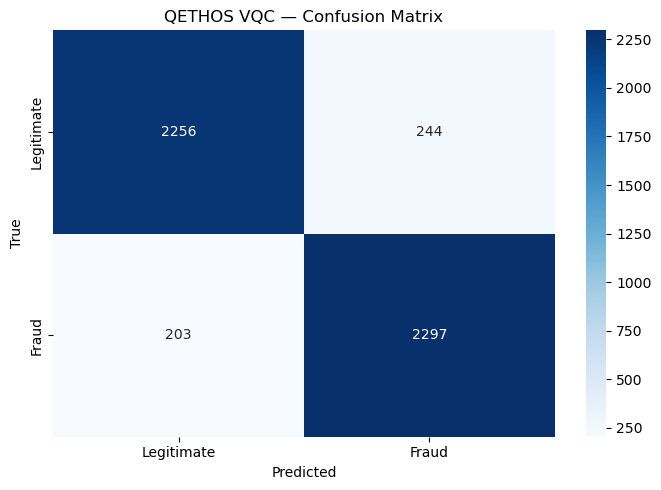

In [19]:
cm = confusion_matrix(y_true, y_pred_vqc)
plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Legitimate','Fraud'], yticklabels=['Legitimate','Fraud'])
plt.title('QETHOS VQC — Confusion Matrix'); plt.ylabel('True'); plt.xlabel('Predicted')
plt.tight_layout(); plt.savefig(f'{OUTPUT_DIR}vqc_confusion_matrix.png', dpi=150); plt.show()

## Step 19 — Classical baselines on the SAME data (configurable)

Controlled by `RUN_BASELINES` in Step 3. When `True`, Random Forest and XGBoost train on the
**identical** training set and quantile preprocessing the VQC saw, scored on the **identical**
test set — the fair head-to-head for the paper. When `False` (the NRP "train VQC only" mode),
these cells are skipped and the comparison table shows just the VQC row.

In [20]:
if not RUN_BASELINES:
    print("RUN_BASELINES=False -> skipping Random Forest baseline.")
else:
    # ----------------------------------------
    # RANDOM FOREST — same train/test as VQC
    # ----------------------------------------
    start = time.time()
    rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    rf_model.fit(X_train_s, y_train)
    rf_train_time = time.time() - start

    start = time.time()
    rf_probs  = rf_model.predict_proba(X_test_s)[:, 1]
    y_pred_rf = (rf_probs > 0.5).astype(int)
    rf_inf_time = time.time() - start

    rf_precision = precision_score(y_true, y_pred_rf)
    rf_recall    = recall_score(y_true, y_pred_rf)
    rf_f1        = f1_score(y_true, y_pred_rf)
    rf_accuracy  = accuracy_score(y_true, y_pred_rf)
    rf_auc       = roc_auc_score(y_true, rf_probs)

    print(f'Random Forest trained in {rf_train_time:.2f}s on {len(X_train_s):,} samples')
    print(f'Precision {rf_precision:.4f} | Recall {rf_recall:.4f} | F1 {rf_f1:.4f} | Acc {rf_accuracy:.4f} | ROC-AUC {rf_auc:.4f}')

RUN_BASELINES=False -> skipping Random Forest baseline.


In [21]:
if not RUN_BASELINES:
    print("RUN_BASELINES=False -> skipping XGBoost baseline.")
else:
    # ----------------------------------------
    # XGBOOST — same train/test as VQC
    # ----------------------------------------
    start = time.time()
    xgb_model = XGBClassifier(n_estimators=100, random_state=RANDOM_SEED,
                              eval_metric='logloss', n_jobs=-1)
    xgb_model.fit(X_train_s, y_train)
    xgb_train_time = time.time() - start

    start = time.time()
    xgb_probs  = xgb_model.predict_proba(X_test_s)[:, 1]
    y_pred_xgb = (xgb_probs > 0.5).astype(int)
    xgb_inf_time = time.time() - start

    xgb_precision = precision_score(y_true, y_pred_xgb)
    xgb_recall    = recall_score(y_true, y_pred_xgb)
    xgb_f1        = f1_score(y_true, y_pred_xgb)
    xgb_accuracy  = accuracy_score(y_true, y_pred_xgb)
    xgb_auc       = roc_auc_score(y_true, xgb_probs)

    print(f'XGBoost trained in {xgb_train_time:.2f}s on {len(X_train_s):,} samples')
    print(f'Precision {xgb_precision:.4f} | Recall {xgb_recall:.4f} | F1 {xgb_f1:.4f} | Acc {xgb_accuracy:.4f} | ROC-AUC {xgb_auc:.4f}')

RUN_BASELINES=False -> skipping XGBoost baseline.


## Step 20 — Comparison Table (same data for every row)

In [22]:
# Comparison table. If RUN_BASELINES=False, only the VQC row is shown.
rows = [{
    "Model": "QETHOS VQC",
    "Training Samples": f"{len(X_train_s):,}",
    "Precision": f"{vqc_precision:.4f}", "Recall": f"{vqc_recall:.4f}",
    "F1-Score": f"{vqc_f1:.4f}", "Accuracy": f"{vqc_accuracy:.4f}", "ROC-AUC": f"{vqc_auc:.4f}",
}]
if RUN_BASELINES:
    rows.append({"Model": "Random Forest", "Training Samples": f"{len(X_train_s):,}",
                 "Precision": f"{rf_precision:.4f}", "Recall": f"{rf_recall:.4f}",
                 "F1-Score": f"{rf_f1:.4f}", "Accuracy": f"{rf_accuracy:.4f}", "ROC-AUC": f"{rf_auc:.4f}"})
    rows.append({"Model": "XGBoost", "Training Samples": f"{len(X_train_s):,}",
                 "Precision": f"{xgb_precision:.4f}", "Recall": f"{xgb_recall:.4f}",
                 "F1-Score": f"{xgb_f1:.4f}", "Accuracy": f"{xgb_accuracy:.4f}", "ROC-AUC": f"{xgb_auc:.4f}"})

df_results = pd.DataFrame(rows)
print("=" * 78)
print("        QETHOS — MODEL COMPARISON" + ("" if RUN_BASELINES else "  (VQC only)"))
print("=" * 78)
try:
    display(df_results)
except NameError:
    print(df_results.to_string(index=False))

df_results.to_csv(f"{OUTPUT_DIR}qethos_results_comparison.csv", index=False)
print("\nResults table saved.")

        QETHOS — MODEL COMPARISON  (VQC only)


,Model,Training Samples,Precision,Recall,F1-Score,Accuracy,ROC-AUC
0,QETHOS VQC,"13,000",0.9040,0.9188,0.9113,0.9106,0.9733



Results table saved.


## Step 21 — Comparison Chart

In [23]:
# Comparison chart. Skipped when RUN_BASELINES=False (nothing to compare against).
if not RUN_BASELINES:
    print("RUN_BASELINES=False -> skipping comparison chart (VQC-only run).")
else:
    models  = ["QETHOS VQC", "Random Forest", "XGBoost"]
    metrics = ["Precision", "Recall", "F1-Score", "Accuracy", "ROC-AUC"]
    vqc_scores = [vqc_precision, vqc_recall, vqc_f1, vqc_accuracy, vqc_auc]
    rf_scores  = [rf_precision,  rf_recall,  rf_f1,  rf_accuracy,  rf_auc]
    xgb_scores = [xgb_precision, xgb_recall, xgb_f1, xgb_accuracy, xgb_auc]

    x, width = np.arange(len(metrics)), 0.25
    fig, ax = plt.subplots(figsize=(13, 6))
    bars1 = ax.bar(x - width, vqc_scores, width, label="QETHOS VQC",    color="purple", alpha=0.8)
    bars2 = ax.bar(x,         rf_scores,  width, label="Random Forest", color="blue",   alpha=0.8)
    bars3 = ax.bar(x + width, xgb_scores, width, label="XGBoost",       color="orange", alpha=0.8)
    for bar in list(bars1) + list(bars2) + list(bars3):
        h = bar.get_height()
        ax.annotate(f"{h:.3f}", xy=(bar.get_x()+bar.get_width()/2, h),
                    xytext=(0, 3), textcoords="offset points", ha="center", va="bottom", fontsize=8)
    ax.set_xlabel("Metric"); ax.set_ylabel("Score")
    ax.set_title(f"QETHOS VQC vs Classical Baselines\n(all models: {len(X_train_s):,} identical training samples, identical test set)")
    ax.set_xticks(x); ax.set_xticklabels(metrics); ax.set_ylim(0, 1.1)
    ax.legend(); ax.grid(True, alpha=0.3, axis="y")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}qethos_comparison_chart.png", dpi=150)
    plt.show()
    print("Comparison chart saved.")

RUN_BASELINES=False -> skipping comparison chart (VQC-only run).


## Step 22 (optional) — Baselines on the full 400k for reference

If you also want the "classical models with unlimited data" reference point for the
paper, run this cell. Report it as a *separate* row clearly labeled with its larger
training-set size — never in the same chart as the matched-data comparison without
the sample counts shown.

In [24]:
RUN_FULL_BASELINES = False   # set True to run (takes longer)

if RUN_FULL_BASELINES:
    X_full = df[AGA_FEATURES].values.astype(np.float32)
    y_full = df[LABEL_COLUMN].values.astype(np.float32)

    X_tr_f, X_te_f, y_tr_f, y_te_f = train_test_split(
        X_full, y_full, test_size=0.30, stratify=y_full, random_state=RANDOM_SEED)

    sc = MinMaxScaler()                      # FIX: import exists now
    X_tr_f = sc.fit_transform(X_tr_f); X_te_f = sc.transform(X_te_f)

    rf_full = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=-1)
    rf_full.fit(X_tr_f, y_tr_f)
    p = rf_full.predict(X_te_f)
    print(f'RF (full {len(X_tr_f):,}) | P {precision_score(y_te_f, p):.4f} | R {recall_score(y_te_f, p):.4f} | F1 {f1_score(y_te_f, p):.4f}')

    xgb_full = XGBClassifier(n_estimators=100, random_state=RANDOM_SEED, eval_metric='logloss', n_jobs=-1)
    xgb_full.fit(X_tr_f, y_tr_f)
    p = xgb_full.predict(X_te_f)
    print(f'XGB (full {len(X_tr_f):,}) | P {precision_score(y_te_f, p):.4f} | R {recall_score(y_te_f, p):.4f} | F1 {f1_score(y_te_f, p):.4f}')
else:
    print('Skipped (set RUN_FULL_BASELINES = True to run).')

Skipped (set RUN_FULL_BASELINES = True to run).


## Step 23 — Adversarial robustness (ART) — same technique as the QSVM notebook

This mirrors the QSVM robustness section so the two models are evaluated **the same way**:
both are attacked with gradient-free-on-the-target methods at matched perturbation budgets.

The VQC is a differentiable PyTorch model, so ART *could* attack it white-box. But to keep the
methodology identical to the QSVM (which can only be attacked by transfer), and to keep the
QSVM-vs-VQC comparison fair, we use the **same two attacks**:

1. **Transfer FGSM + PGD** via one shared surrogate (logistic regression) trained on the same
   quantile-encoded features. The *same* adversarial samples are scored by the VQC.
2. **Black-box HopSkipJump** querying the VQC's own predictions (gradient-free).

Everything operates in the VQC's encoded space, which is **[-1, 1]** (quantile ×2−1), so the
surrogate, clip values, and epsilon budgets are all set for that range. Controlled by `RUN_ART`
and `RUN_HSJ` in Step 3.

In [25]:
import art
print("ART", art.__version__)

from sklearn.linear_model import LogisticRegression
from art.estimators.classification import SklearnClassifier, BlackBoxClassifier
from art.attacks.evasion import FastGradientMethod, ProjectedGradientDescent, HopSkipJump

# ---- helper: VQC label predictions for any encoded feature matrix in [-1, 1] ----
def vqc_predict_labels(Xfeat, thresh=None):
    thresh = best_t if thresh is None else thresh
    model.eval()
    with torch.no_grad():
        p = torch.sigmoid(model(torch.tensor(np.asarray(Xfeat), dtype=torch.float32).to(DEVICE))).cpu().numpy()
    return (p > thresh).astype(int)

ENC_LO, ENC_HI = -1.0, 1.0   # the VQC's encoded range (quantile*2-1)

ART 1.20.1


In [26]:
if not RUN_ART:
    print("RUN_ART=False -> skipping adversarial robustness.")
else:
    # attack set: a fresh slice of the encoded TEST set
    X_adv0 = X_test_s[:ART_N_ADV].astype(np.float32)
    y_adv0 = y_test[:ART_N_ADV].astype(int)

    vqc_clean = vqc_predict_labels(X_adv0)
    print(f"CLEAN VQC | F1={f1_score(y_adv0,vqc_clean,zero_division=0):.4f} "
          f"acc={accuracy_score(y_adv0,vqc_clean):.4f}")

    # shared surrogate on the SAME encoded features (technique identical to QSVM notebook)
    surrogate = LogisticRegression(max_iter=1000).fit(X_train_s, y_train.astype(int))
    art_surr  = SklearnClassifier(model=surrogate, clip_values=(ENC_LO, ENC_HI))

    rows = []
    for eps in ART_EPSILONS:
        for name, atk in [
            ("FGSM", FastGradientMethod(estimator=art_surr, eps=eps)),
            ("PGD",  ProjectedGradientDescent(estimator=art_surr, eps=eps,
                                              eps_step=eps/4, max_iter=10, verbose=False)),
        ]:
            Xadv = atk.generate(x=X_adv0)
            v = vqc_predict_labels(Xadv)
            r = {"attack": name, "eps": eps,
                 "VQC_F1": f1_score(y_adv0, v, zero_division=0),
                 "VQC_acc": accuracy_score(y_adv0, v)}
            rows.append(r)
            print(f"{name:4s} eps={eps:<4} | VQC F1={r['VQC_F1']:.3f} acc={r['VQC_acc']:.3f}")

    art_df = pd.DataFrame(rows)
    art_df.to_csv(f"{OUTPUT_DIR}vqc_art_transfer.csv", index=False)
    art_df

CLEAN VQC | F1=0.8945 acc=0.8950
FGSM eps=0.05 | VQC F1=0.879 acc=0.880
PGD  eps=0.05 | VQC F1=0.879 acc=0.880
FGSM eps=0.1  | VQC F1=0.726 acc=0.705
PGD  eps=0.1  | VQC F1=0.726 acc=0.705
FGSM eps=0.2  | VQC F1=0.559 acc=0.590
PGD  eps=0.2  | VQC F1=0.559 acc=0.590
FGSM eps=0.3  | VQC F1=0.540 acc=0.565
PGD  eps=0.3  | VQC F1=0.540 acc=0.565
FGSM eps=0.5  | VQC F1=0.379 acc=0.345
PGD  eps=0.5  | VQC F1=0.379 acc=0.345


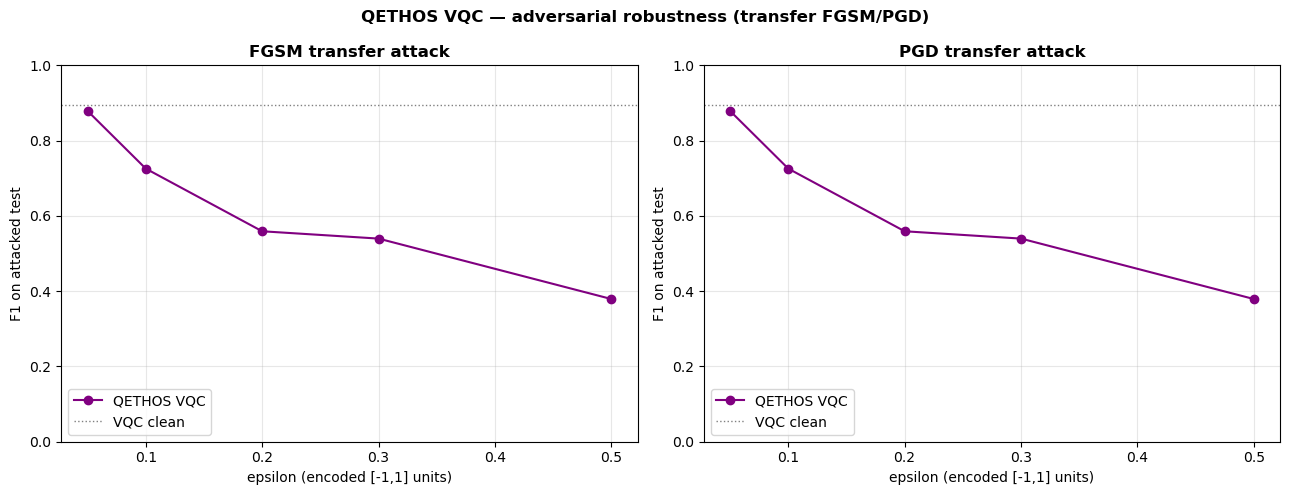

In [27]:
# Robustness degradation curves (transfer attacks)
if RUN_ART:
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    clean_f1 = f1_score(y_adv0, vqc_clean, zero_division=0)
    for ax, atk in zip(axes, ["FGSM", "PGD"]):
        sub = art_df[art_df.attack == atk]
        ax.plot(sub.eps, sub.VQC_F1, "o-", color="purple", label="QETHOS VQC")
        ax.axhline(clean_f1, color="gray", ls=":", lw=1, label="VQC clean")
        ax.set_title(f"{atk} transfer attack", fontweight="bold")
        ax.set_xlabel("epsilon (encoded [-1,1] units)"); ax.set_ylabel("F1 on attacked test")
        ax.set_ylim(0, 1); ax.legend(); ax.grid(alpha=0.3)
    plt.suptitle("QETHOS VQC — adversarial robustness (transfer FGSM/PGD)", fontweight="bold")
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}vqc_art_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("RUN_ART=False -> no curves.")

In [ ]:
# Black-box HopSkipJump on the VQC (gradient-free; same attack used on the QSVM)
if RUN_ART and RUN_HSJ:
    Xh = X_test_s[:ART_N_HSJ].astype(np.float32); yh = y_test[:ART_N_HSJ].astype(int)

    def vqc_bb_predict(x):
        x = np.asarray(x, dtype=np.float32)
        model.eval()
        with torch.no_grad():
            p = torch.sigmoid(model(torch.tensor(x).to(DEVICE))).cpu().numpy()
        oh = np.zeros((len(p), 2)); oh[:, 1] = p; oh[:, 0] = 1 - p
        return oh

    art_vqc = BlackBoxClassifier(predict_fn=vqc_bb_predict, input_shape=(N_QUBITS,),
                                 nb_classes=2, clip_values=(ENC_LO, ENC_HI))
    hsj = HopSkipJump(classifier=art_vqc, max_iter=10, max_eval=300, init_eval=20, verbose=False)
    Xq = hsj.generate(x=Xh)
    q = vqc_predict_labels(Xq)
    print(f"HSJ VQC | F1={f1_score(yh,q,zero_division=0):.3f} acc={accuracy_score(yh,q):.3f}")
    pd.DataFrame([{"model":"VQC","attack":"HopSkipJump",
                   "F1":f1_score(yh,q,zero_division=0),"acc":accuracy_score(yh,q)}]
                ).to_csv(f"{OUTPUT_DIR}vqc_art_hsj.csv", index=False)
else:
    print("RUN_HSJ/RUN_ART off -> skipping HopSkipJump.")